In [117]:
import os
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [118]:
TRAIN_DIR = '/Users/shivanshuprakash/Desktop/models2/input'
TEST_DIR = '/Users/shivanshuprakash/Desktop/models2/store'

In [119]:
def createdataframe(dir):
    image_paths = []
    labels = []
    for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
            image_paths.append(os.path.join(dir,label,imagename))
            labels.append(label)
        print(label, "completed")
    return image_paths,labels

In [120]:
train = pd.DataFrame()
train['image'], train['label'] = createdataframe(TRAIN_DIR)

Car completed
Van completed
Motorcycle completed
Truck completed


In [121]:
print(train)

                                                   image  label
0      /Users/shivanshuprakash/Desktop/models2/input/...    Car
1      /Users/shivanshuprakash/Desktop/models2/input/...    Car
2      /Users/shivanshuprakash/Desktop/models2/input/...    Car
3      /Users/shivanshuprakash/Desktop/models2/input/...    Car
4      /Users/shivanshuprakash/Desktop/models2/input/...    Car
...                                                  ...    ...
17084  /Users/shivanshuprakash/Desktop/models2/input/...  Truck
17085  /Users/shivanshuprakash/Desktop/models2/input/...  Truck
17086  /Users/shivanshuprakash/Desktop/models2/input/...  Truck
17087  /Users/shivanshuprakash/Desktop/models2/input/...  Truck
17088  /Users/shivanshuprakash/Desktop/models2/input/...  Truck

[17089 rows x 2 columns]


In [122]:
test = pd.DataFrame()
test['image'], test['label'] = createdataframe(TEST_DIR)

Car completed
Van completed
Motorcycle completed
Truck completed


In [123]:
print(test)

                                                   image  label
0      /Users/shivanshuprakash/Desktop/models2/store/...    Car
1      /Users/shivanshuprakash/Desktop/models2/store/...    Car
2      /Users/shivanshuprakash/Desktop/models2/store/...    Car
3      /Users/shivanshuprakash/Desktop/models2/store/...    Car
4      /Users/shivanshuprakash/Desktop/models2/store/...    Car
...                                                  ...    ...
17083  /Users/shivanshuprakash/Desktop/models2/store/...  Truck
17084  /Users/shivanshuprakash/Desktop/models2/store/...  Truck
17085  /Users/shivanshuprakash/Desktop/models2/store/...  Truck
17086  /Users/shivanshuprakash/Desktop/models2/store/...  Truck
17087  /Users/shivanshuprakash/Desktop/models2/store/...  Truck

[17088 rows x 2 columns]


In [124]:
from tqdm import tqdm

In [125]:
import cv2
import os

# Define the directory containing images and the desired resolution
input_dir = '/Users/shivanshuprakash/Desktop/models2/input/Truck'
output_dir = '/Users/shivanshuprakash/Desktop/models2/store/Truck'
new_size = (48, 48)  # New resolution (width, height)

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Loop through all images in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('jpeg'):  # Add other formats as needed
        img_path = os.path.join(input_dir, filename)
        img = cv2.imread(img_path)
        img_resized = cv2.resize(img, new_size)  # Resize image
        cv2.imwrite(os.path.join(output_dir, filename), img_resized)  # Save resized image

In [126]:
import cv2
import os

# Define the directory containing images and the desired resolution
input_dir = '/Users/shivanshuprakash/Desktop/models2/input/Car'
output_dir = '/Users/shivanshuprakash/Desktop/models2/store/Car'
new_size = (48, 48)  # New resolution (width, height)

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Loop through all images in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('jpeg'):  # Add other formats as needed
        img_path = os.path.join(input_dir, filename)
        img = cv2.imread(img_path)
        img_resized = cv2.resize(img, new_size)  # Resize image
        cv2.imwrite(os.path.join(output_dir, filename), img_resized)  # Save resized image

In [127]:
import cv2
import os

# Define the directory containing images and the desired resolution
input_dir = '/Users/shivanshuprakash/Desktop/models2/input/Motorcycle'
output_dir = '/Users/shivanshuprakash/Desktop/models2/store/Motorcycle'
new_size = (48, 48)  # New resolution (width, height)

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Loop through all images in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('jpeg'):  # Add other formats as needed
        img_path = os.path.join(input_dir, filename)
        img = cv2.imread(img_path)
        img_resized = cv2.resize(img, new_size)  # Resize image
        cv2.imwrite(os.path.join(output_dir, filename), img_resized)  # Save resized image

In [128]:
import cv2
import os

# Define the directory containing images and the desired resolution
input_dir = '/Users/shivanshuprakash/Desktop/models2/input/Van'
output_dir = '/Users/shivanshuprakash/Desktop/models2/store/Van'
new_size = (48, 48)  # New resolution (width, height)

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Loop through all images in the input directory
for filename in os.listdir(input_dir):
    if filename.endswith('.jpg') or filename.endswith('.png') or filename.endswith('jpeg'):  # Add other formats as needed
        img_path = os.path.join(input_dir, filename)
        img = cv2.imread(img_path)
        img_resized = cv2.resize(img, new_size)  # Resize image
        cv2.imwrite(os.path.join(output_dir, filename), img_resized)  # Save resized image

In [129]:
from tensorflow.keras.preprocessing.image import load_img
import cv2
import os
def extract_features(images, target_size=(48, 48)):
    features = []
    for image_path in images:
        try:
            # Load and resize the image
            img = load_img(image_path, color_mode='rgb', target_size=target_size)
            img_array = np.array(img)
            features.append(img_array)
        except Exception as e:
            print(f"Skipping {image_path} due to error: {e}")
            continue
    return np.array(features)

In [130]:
train_features = extract_features(train['image']) 

/Users/shivanshuprakash/Desktop/models2/myenv/lib/python3.11/site-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [131]:
test_features = extract_features(test['image'])

In [132]:
x_train = train_features/255.0
x_test = test_features/255.0

In [133]:
from sklearn.preprocessing import LabelEncoder

In [134]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [135]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])

In [136]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train,num_classes = 4)
y_test = to_categorical(y_test,num_classes = 4)

In [137]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input
from tensorflow.keras.regularizers import l2

# Define the model
model = Sequential()

# Input layer
model.add(Input(shape=(48, 48, 3)))

# Convolutional layers
model.add(Conv2D(64, (3, 3), 1, activation='tanh', kernel_regularizer=l2(0.005)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(128, (3, 3), 1, activation='relu', kernel_regularizer=l2(0.005)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(256,(3, 3),1 ,  activation='relu', kernel_regularizer=l2(0.005)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

model.add(Conv2D(256,(3, 3),1,  activation='relu', kernel_regularizer=l2(0.005)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

# Fully connected layers
model.add(Flatten())
model.add(Dense(256, activation='tanh', kernel_regularizer=l2(0.005)))
model.add(Dropout(0.4))

# Output layer
model.add(Dense(4, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 46, 46, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027,716 (3.92 MB)

 Trainable params: 1,027,716 (3.92 MB)

 Non-trainable params: 0 (0.00 B)

In [138]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an instance of ImageDataGenerator
datagen = ImageDataGenerator(rescale=1./255)

# Load images from a directory
train_generator = datagen.flow_from_directory(
    '/Users/shivanshuprakash/Desktop/models2/store',  # Path to your dataset
    target_size=(48, 48),        # Resize images
    batch_size=32,                 # Set batch size
    class_mode='categorical'       # Choose class mode
)
val_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/Users/shivanshuprakash/Desktop/models2/store',
    target_size=(48, 48),
    batch_size=32,
    class_mode='categorical'
)

# Get a batch of data
images, labels = next(train_generator)

# Check the shape of the images and labels
print("Images shape:", images.shape)  # Should be (batch_size, height, width, channels)
print("Labels shape:", labels.shape)  # Should be (batch_size, num_classes)

# Print the labels
print("Labels (array format):")
print(labels)

# If you want to see the class indices
print("Class indices:", train_generator.class_indices)

Found 17088 images belonging to 4 classes.
Found 17088 images belonging to 4 classes.
Images shape: (32, 48, 48, 3)
Labels shape: (32, 4)
Labels (array format):
[[0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]]
Class indices: {'Car': 0, 'Motorcycle': 1, 'Truck': 2, 'Van': 3}


In [139]:
logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
hist = model.fit(train_generator, epochs = 20, validation_data = val_generator, callbacks = [tensorboard_callback]) 

Epoch 1/20


/Users/shivanshuprakash/Desktop/models2/myenv/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 53s 98ms/step - accuracy: 0.8060 - loss: 1.2766 - val_accuracy: 0.8812 - val_loss: 0.5475
Epoch 2/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 53s 99ms/step - accuracy: 0.8700 - loss: 0.5585 - val_accuracy: 0.8904 - val_loss: 0.4839
Epoch 3/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 58s 109ms/step - accuracy: 0.8849 - loss: 0.5100 - val_accuracy: 0.9083 - val_loss: 0.4391
Epoch 4/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 67s 125ms/step - accuracy: 0.8920 - loss: 0.4929 - val_accuracy: 0.8590 - val_loss: 0.5767
Epoch 5/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 60s 113ms/step - accuracy: 0.8962 - loss: 0.4871 - val_accuracy: 0.8952 - val_loss: 0.4677
Epoch 6/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 55s 102ms/step - accuracy: 0.9019 - loss: 0.4660 - val_accuracy: 0.9086 - val_loss: 0.4197
Epoch 7/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 58s 109ms/step - accuracy: 0.9056 - loss: 0.4612 - val_accuracy: 0.9151 - val_loss: 0.4120
Epoch 8/20
534/534 ━━━━━━━━━━━━━━━━━━━━ 64s 120ms/step - accuracy: 0.9068 - loss: 0.4524 - val_a

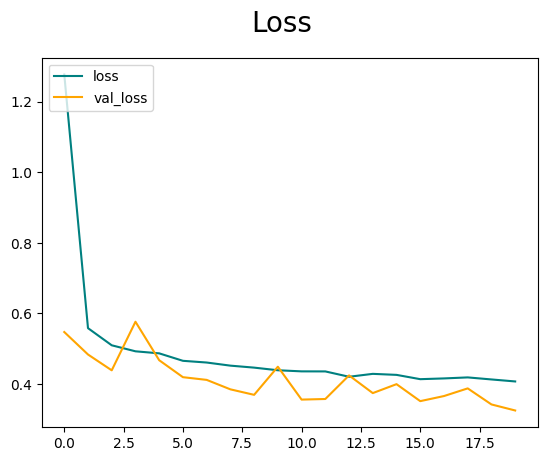

In [140]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'teal', label = 'loss')
plt.plot(hist.history['val_loss'], color = 'orange', label = 'val_loss')
fig.suptitle('Loss', fontsize = 20)
plt.legend(loc = 'upper left')
plt.show()


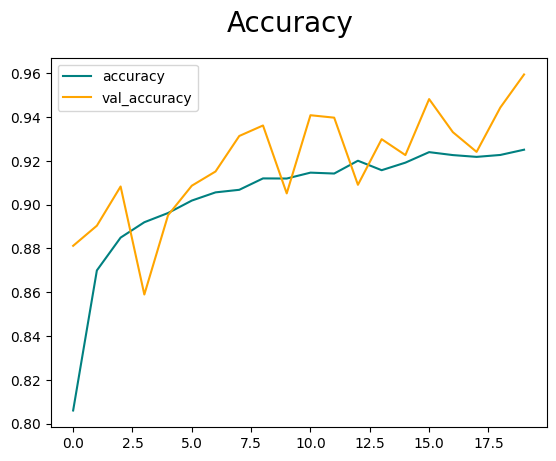

In [141]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'teal', label = 'accuracy')
plt.plot(hist.history['val_accuracy'], color = 'orange', label = 'val_accuracy')
fig.suptitle('Accuracy', fontsize = 20)
plt.legend(loc = 'upper left')
plt.show()

In [142]:
model.evaluate(val_generator)



534/534 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9594 - loss: 0.3254


[0.32543909549713135, 0.9594452381134033]

In [ ]:
from tensorflow.keras.models import  load_model
model.save(os.path.join('models', 'vehicledetectmodel.h5'))


In [1]:
import tensorflow as tf

# Replace 'my_vehicle_classifier_model' with the name of your saved model's directory
loaded_model = tf.keras.models.load_model('/Users/shivanshuprakash/Desktop/models2/models/vehicledetectmodel.h5')

In [5]:
import numpy as np
from tensorflow.keras.preprocessing import image

# The target size must match the size your model was trained on
IMG_SIZE = 48

# Path to the image you want to test
image_path = '/Users/shivanshuprakash/Desktop/models2/car.jpg' 

# Load the image and resize it to the correct dimensions
img = image.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))

# Convert the image to a NumPy array
img_array = image.img_to_array(img)

# The model expects a batch of images, so add a dimension
# The shape goes from (600, 600, 3) to (1, 600, 600, 3)
img_array = np.expand_dims(img_array, axis=0)

# Normalize the image (scale pixel values from 0-255 to 0-1)
normalized_img_array = img_array / 255.0

In [6]:
# Make the prediction
predictions = loaded_model.predict(normalized_img_array)

# The prediction is an array of probabilities.
# np.argmax() returns the index of the highest probability.
predicted_class_index = np.argmax(predictions[0])
confidence = np.max(predictions[0])

# Get your class names
# You need to have a list of class names in the same order as your training data
class_names = ['Car', 'Motorcycle', 'Truck', 'Van'] # Replace with your class names

predicted_class = class_names[predicted_class_index]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [7]:
print(f"The model predicted: {predicted_class}")
print(f"Confidence: {confidence:.2f}")

# Example of a correct prediction
if predicted_class == 'Car':
    print("Prediction is correct! ")
else:
    print("Prediction is incorrect. ")

The model predicted: Car
Confidence: 0.96
Prediction is correct! 
